In [1]:
import time
import pickle
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew

from skimage import graph
from skimage.filters import sobel
from skimage.util import img_as_float
from skimage.segmentation import slic, mark_boundaries
from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

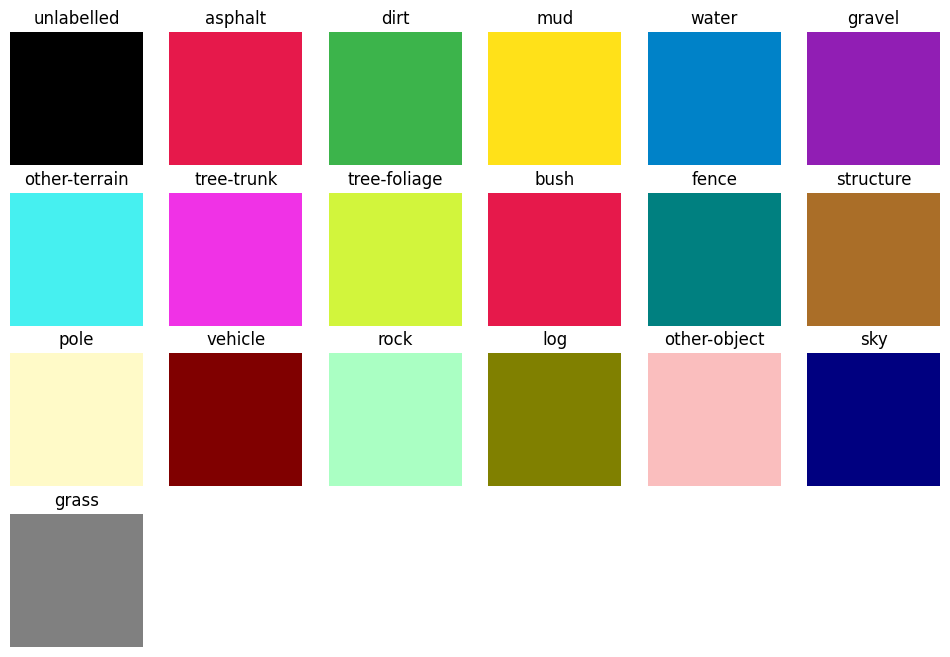

In [2]:
palette = [
    [0, 0, 0],
    [230, 25, 75],
    [60, 180, 75],
    [255, 225, 25],
    [0, 130, 200],
    [145, 30, 180],
    [70, 240, 240],
    [240, 50, 230],
    [210, 245, 60],
    [230, 25, 75],
    [0, 128, 128],
    [170, 110, 40],
    [255, 250, 200],
    [128, 0, 0],
    [170, 255, 195],
    [128, 128, 0],
    [250, 190, 190],
    [0, 0, 128],
    [128, 128, 128],
]

label_names = ["unlabelled",
        "asphalt",
        "dirt",
        "mud",
        "water",
        "gravel",
        "other-terrain",
        "tree-trunk",
        "tree-foliage",
        "bush",
        "fence",
        "structure",
        "pole",
        "vehicle",
        "rock",
        "log",
        "other-object",
        "sky",
        "grass"
]

label_dict = {i:name for i, name in zip(range(19), label_names)}
plt.figure(figsize=(12, 8))
for k, v in label_dict.items():
    plt.subplot(4, 6, k+1)
    plt.imshow(np.array([[palette[k]]]))
    plt.title(v)
    plt.axis("off")
plt.show()

In [3]:
def visualise_prediction(pred, palette):
    """convert class index to palette for visualisation"""
    pred_img = []
    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            pred_img.append(palette[pred[i][j]])
    pred_img = np.array(pred_img).reshape(img.shape)
    return pred_img

def get_superpixel(img, mask):
    """
    given original image and segmentation mask, get the superpixel image and mask
    img : original image, 3d array
    mask : binary mask, 2d array of dtype uint8
    """
    h, w = mask.shape
    
    # finding the cropping index
    temp_h = np.matmul(mask, np.ones((w, 1), dtype=int)).flatten()
    temp_h_bool = (temp_h != 0).astype(int).tolist()
    top = temp_h_bool.index(1)
    reversed_temp_h_bool = list(reversed(temp_h_bool[top:]))
    bottom = h - reversed_temp_h_bool.index(1)
    
    temp_w = np.matmul(np.ones((bottom-top), dtype=int), mask[top:bottom, :])
    temp_w_bool = (temp_w != 0).astype(int).tolist()
    left = temp_w_bool.index(1)
    reversed_temp_w_bool = list(reversed(temp_w_bool[left:]))
    right = w - reversed_temp_w_bool.index(1)
    
    # cropping
    superpixel_mask = mask[top:bottom, left:right]
    superpixel_mask_3d = np.repeat(superpixel_mask[:, :, np.newaxis], 3, axis=2) * 255
    cropped_img = img[top:bottom, left:right, :]
    superpixel_img = cv2.bitwise_and(cropped_img, superpixel_mask_3d)
        
    return superpixel_img, superpixel_mask

def feature_extraction(superpixel_img, superpixel_mask):
    """
    extract color, texture features from the superpixel image
    color feature : color moments (mean, sd, skewness) --> 9 features
    texture feature : local binary patterns histogram (rotation-invariant) --> 36 features
    returns a list of features (size 45) of the superpixel image
    """
    
    # color features
    red_pixels = [value for value, in_mask in zip(superpixel_img[:, :, 0].flatten().tolist(), superpixel_mask.flatten().tolist()) if in_mask]
    green_pixels = [value for value, in_mask in zip(superpixel_img[:, :, 1].flatten().tolist(), superpixel_mask.flatten().tolist()) if in_mask]
    blue_pixels = [value for value, in_mask in zip(superpixel_img[:, :, 2].flatten().tolist(), superpixel_mask.flatten().tolist()) if in_mask]
    
    red_all_equal = all([value == red_pixels[0] for value in red_pixels])
    if red_all_equal:
        red_moments = [red_pixels[0], 0, 0]
    else:
        red_moments = [np.mean(red_pixels), np.std(red_pixels), skew(red_pixels)]
    
    green_all_equal = all([value == green_pixels[0] for value in green_pixels])
    if green_all_equal:
        green_moments = [green_pixels[0], 0, 0]
    else:
        green_moments = [np.mean(green_pixels), np.std(green_pixels), skew(green_pixels)]
        
    blue_all_equal = all([value == blue_pixels[0] for value in blue_pixels])
    if blue_all_equal:
        blue_moments = [blue_pixels[0], 0, 0]
    else:
        blue_moments = [np.mean(blue_pixels), np.std(blue_pixels), skew(blue_pixels)]
        
    # texture features
    LBP_POSSIBLE_VALUES = [  0,   1,   3,   5,   7,   9,  11,  13,  15,  17,  19,  21,  23,
                               25,  27,  29,  31,  37,  39,  43,  45,  47,  51,  53,  55,  59,
                               61,  63,  85,  87,  91,  95, 111, 119, 127, 255]
    
    gray_superpixel_img = cv2.cvtColor(superpixel_img, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray_superpixel_img, 8, 1, method="ror").astype(int)
    lbp_in_mask = [value for value, in_mask in zip(lbp.flatten().tolist(), superpixel_mask.flatten().tolist()) if in_mask]
    lbp_hist = [lbp_in_mask.count(lbp_value) for lbp_value in LBP_POSSIBLE_VALUES]
    lbp_hist = [value / np.sum(lbp_hist) for value in lbp_hist]
    
    all_features = red_moments + green_moments + blue_moments + lbp_hist
    
    return all_features

def _weight_mean_color(graph, src, dst, n):
    """Callback to handle merging nodes by recomputing mean color.

    The method expects that the mean color of `dst` is already computed.

    Parameters
    ----------
    graph : RAG
        The graph under consideration.
    src, dst : int
        The vertices in `graph` to be merged.
    n : int
        A neighbor of `src` or `dst` or both.

    Returns
    -------
    data : dict
        A dictionary with the `"weight"` attribute set as the absolute
        difference of the mean color between node `dst` and `n`.
    """

    diff = graph.nodes[dst]['mean color'] - graph.nodes[n]['mean color']
    diff = np.linalg.norm(diff)
    return {'weight': diff}


def merge_mean_color(graph, src, dst):
    """
    Callback called before merging two nodes of a mean color distance graph.

    This method computes the mean color of `dst`.

    Parameters
    ----------
    graph : RAG
        The graph under consideration.
    src, dst : int
        The vertices in `graph` to be merged.
    """
    graph.nodes[dst]['total color'] += graph.nodes[src]['total color']
    graph.nodes[dst]['pixel count'] += graph.nodes[src]['pixel count']
    graph.nodes[dst]['mean color'] = (
        graph.nodes[dst]['total color'] / graph.nodes[dst]['pixel count']
    )

def change_label(label):
    """
    combine class "asphalt" with "other-terrain", "pole" with "other-object"
    """
    label_copy = np.array(label)
    h, w = label_copy.shape
    
    for i in range(h):
        for j in range(w):
            if label_copy[i, j] == 1:
                label_copy[i, j] = 6
            if label_copy[i, j] == 12:
                label_copy[i, j] = 16
    return label_copy

def jaccard(true_label, pred_label):
    intersection = np.sum(true_label & pred_label)
    union = np.sum(true_label | pred_label)
    if union == 0:
        return 0
    else:
        return intersection / union

In [4]:
def change_path(path):
    my_dir = "C:/Users/david/AI_project/COMP9517/Project/raw_data/"
    return os.path.join(my_dir, path)

# files from github repo under WildScenes/data/splits/opt2d
csv_dir = "C:/Users/david/AI_project/COMP9517/Project/"
train_df = pd.read_csv(os.path.join(csv_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(csv_dir, "test.csv"))
print(len(train_df))
print(len(val_df))
print(len(test_df))

train_df["im_path"] = train_df["im_path"].apply(change_path)
train_df["label_path"] = train_df["label_path"].apply(change_path)
val_df["im_path"] = val_df["im_path"].apply(change_path)
val_df["label_path"] = val_df["label_path"].apply(change_path)
test_df["im_path"] = test_df["im_path"].apply(change_path)
test_df["label_path"] = test_df["label_path"].apply(change_path)

6051
283
2133


## Extract features from training dataset for training ML model

In [5]:
X = []
y = []
for img_path, label_path in zip(train_df["im_path"], train_df["label_path"]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label_img = cv2.imread(label_path)[:, :, 0]
    
#     plt.imshow(img)
#     plt.show()
    
    label_index_list = np.unique(label_img).tolist()
    
    for label_index in label_index_list:
        mask = (label_img == label_index).astype(np.uint8)
        
        superpixel_img, superpixel_mask = get_superpixel(img, mask)
        
        print(f"Class : {label_names[label_index]}")
        
#         plt.figure(figsize=(12, 6))
#         plt.subplot(1, 2, 1)
#         plt.imshow(superpixel_mask, cmap="gray")
#         plt.subplot(1, 2, 2)
#         plt.imshow(superpixel_img)
#         plt.show()

        X.append(feature_extraction(superpixel_img, superpixel_mask))
        y.append(label_index)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## ML model 1 : SGD Classifier

Accuracy: 0.6116697351649908
Precision: 0.6116697351649908
Recall: 0.6116697351649908
F1: 0.6116697351649908


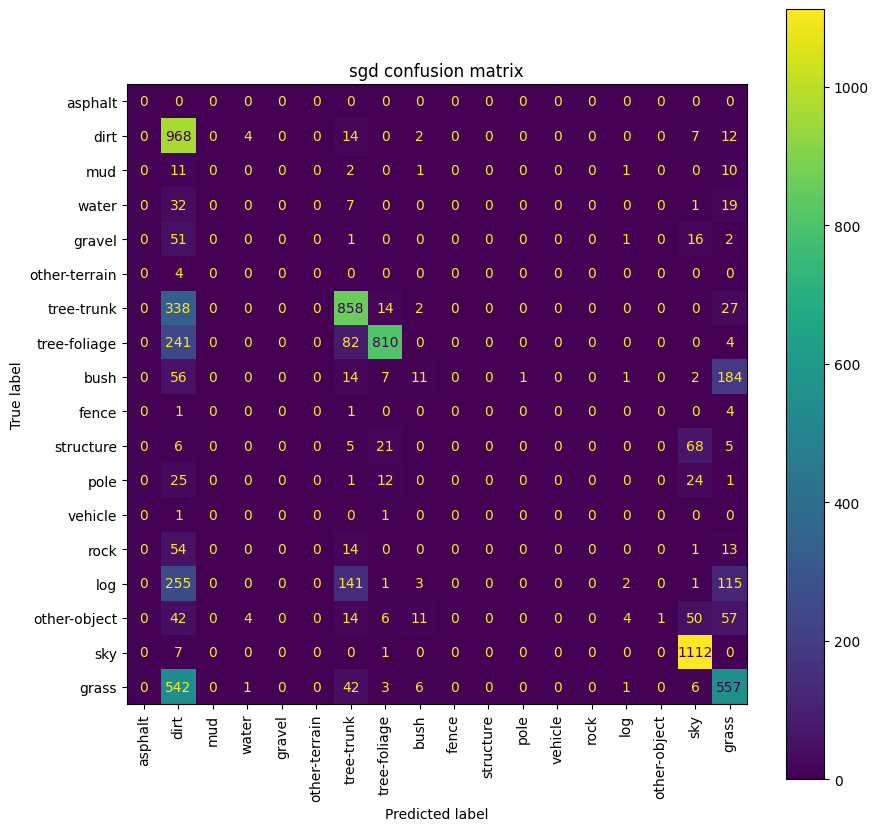

In [7]:
sgd_model = SGDClassifier(max_iter=500, random_state=42)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_pred)
sgd_precision = precision_score(y_test, sgd_pred, average="micro")
sgd_recall = recall_score(y_test, sgd_pred, average="micro")
sgd_f1 = f1_score(y_test, sgd_pred, average="micro")

print(f"Accuracy: {sgd_accuracy}")
print(f"Precision: {sgd_precision}")
print(f"Recall: {sgd_recall}")
print(f"F1: {sgd_f1}")

sgd_cm = confusion_matrix(y_test, sgd_pred, labels=sgd_model.classes_)
sgd_cmd = ConfusionMatrixDisplay(sgd_cm, display_labels=label_names[1:])
fig, ax = plt.subplots(figsize=(10, 10))
plt.title("sgd confusion matrix")
sgd_cmd.plot(ax=ax, xticks_rotation="vertical")

# save model
with open("sgd_model.pkl","wb") as f:
    pickle.dump(sgd_model, f)

# load model
with open("sgd_model.pkl", "rb") as f:
    sgd_model = pickle.load(f)

## ML model 2 : Random Forest Classifier

Accuracy: 0.8612094604163716
Precision: 0.8612094604163716
Recall: 0.8612094604163716
F1: 0.8612094604163716


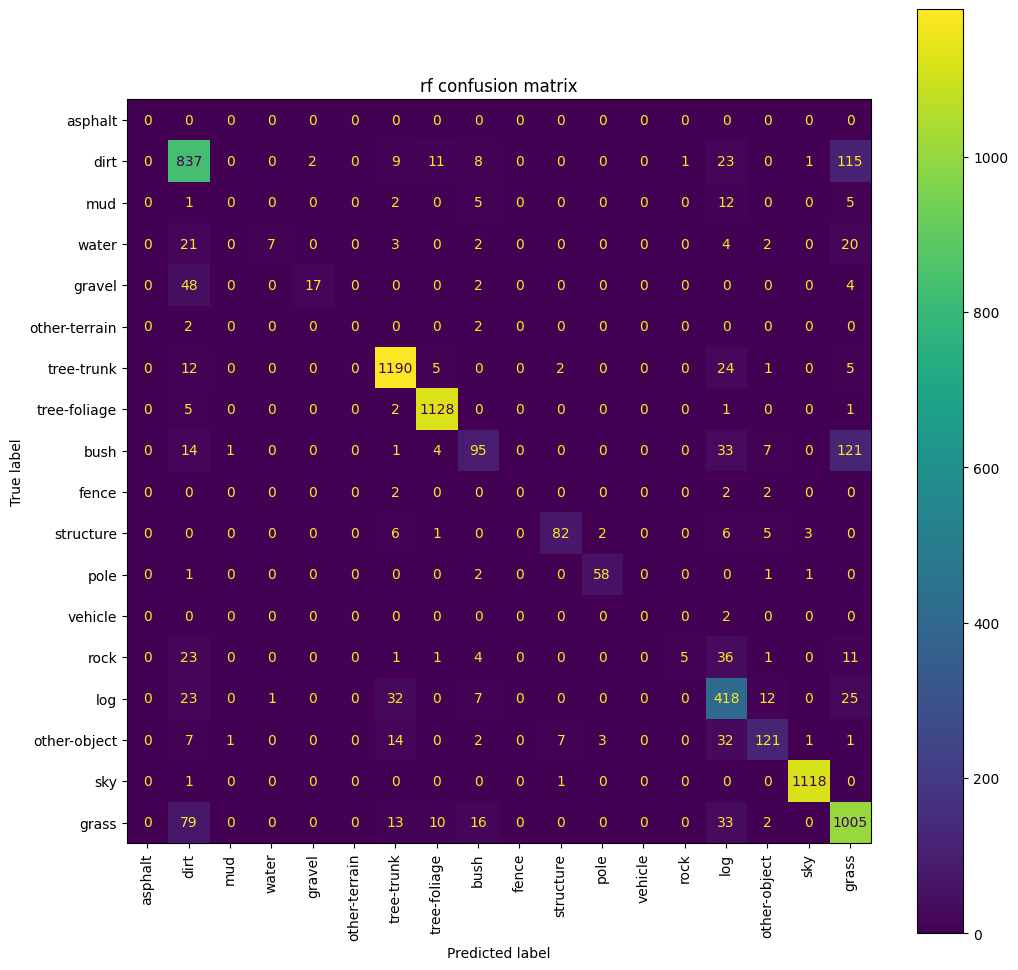

In [8]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="micro")
rf_recall = recall_score(y_test, rf_pred, average="micro")
rf_f1 = f1_score(y_test, rf_pred, average="micro")

print(f"Accuracy: {rf_accuracy}")
print(f"Precision: {rf_precision}")
print(f"Recall: {rf_recall}")
print(f"F1: {rf_f1}")

rf_cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)
rf_cmd = ConfusionMatrixDisplay(rf_cm, display_labels=label_names[1:])
fig, ax = plt.subplots(figsize=(12, 12))
plt.title("rf confusion matrix")
rf_cmd.plot(ax=ax, xticks_rotation="vertical")

# save model
with open("rf_model.pkl","wb") as f:
    pickle.dump(rf_model, f)

# load model
with open("rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

## Prediction for new image

In [9]:
%%time

class_index_list = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18]
sgd_all_iou = [[] for _ in range(15)]
rf_all_iou = [[] for _ in range(15)]

for img_path, label_path in zip(test_df["im_path"], test_df["label_path"]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized_img = img[::2, ::2]
    
    # spliting image into superpixel by Simple Linear Iterative Clustering (SLIC)
    segments = slic(resized_img, n_segments=500, compactness=5, sigma=1)
    
    # merging superpixels
    g = graph.rag_mean_color(resized_img, segments)

    merged_segments = graph.merge_hierarchical(
        segments,
        g,
        thresh = 45,
        rag_copy = False,
        in_place_merge = True,
        merge_func = merge_mean_color,
        weight_func = _weight_mean_color,
    )
    
#     plt.figure(figsize=(12, 6))
#     plt.subplot(1, 2, 1)
#     plt.title(f"{len(np.unique(segments))} segments")
#     plt.imshow(mark_boundaries(resized_img, segments))

#     plt.subplot(1, 2, 2)
#     plt.title(f"{len(np.unique(merged_segments))} segments after merging")
#     plt.imshow(mark_boundaries(resized_img, merged_segments))
#     plt.show()
    
    # double the size to original
    merged_segments = np.repeat(np.repeat(merged_segments, 2, axis=0), 2, axis=1)
    
    # feature extraction and ML model for each superpixel
    sgd_prediction = np.zeros((merged_segments.shape), dtype=int)
    rf_prediction = np.zeros((merged_segments.shape), dtype=int)
    for segment_label in np.unique(merged_segments):
        segmentation_mask = (merged_segments == segment_label).astype(np.uint8)
        superpixel_img, superpixel_mask = get_superpixel(img, segmentation_mask)
        
        superpixel_feature = feature_extraction(superpixel_img, superpixel_mask)
        
        sgd_superpixel_pred_label = sgd_model.predict([superpixel_feature])[0]
        rf_superpixel_pred_label = rf_model.predict([superpixel_feature])[0]
        
        sgd_prediction += sgd_superpixel_pred_label * segmentation_mask
        rf_prediction += rf_superpixel_pred_label * segmentation_mask
    
    label_img = cv2.imread(label_path)
    true_label = label_img[:, :, 0]
    
    for n, class_index in enumerate(class_index_list):
        class_true_label = (true_label == class_index).flatten()
        
        sgd_class_pred_label = (sgd_prediction == class_index).flatten()
        rf_class_pred_label = (rf_prediction == class_index).flatten()
        
        sgd_score = jaccard(class_true_label, sgd_class_pred_label)
        rf_score = jaccard(class_true_label, rf_class_pred_label)

        sgd_all_iou[n].append(sgd_score)
        rf_all_iou[n].append(rf_score)
        
#     plt.figure(figsize=(12, 10))
#     plt.subplot(2, 2, 1)
#     plt.imshow(img)
    
#     plt.subplot(2, 2, 2)
#     true_label_img = visualise_prediction(true_label, palette)
#     plt.title("ground truth")
#     plt.imshow(true_label_img)
    
#     plt.subplot(2, 2, 3) 
#     sgd_pred_img = visualise_prediction(sgd_prediction, palette)
#     plt.title("SGD")
#     plt.imshow(sgd_pred_img)
    
#     plt.subplot(2, 2, 4)    
#     rf_pred_img = visualise_prediction(rf_prediction, palette)
#     plt.title("RF")
#     plt.imshow(rf_pred_img)
    
#     plt.show()


sgd_all_iou = [np.mean(score) for score in sgd_all_iou]
print("Jaccard Score for SGD:")
for class_index, class_iou in zip(class_index_list, sgd_all_iou):
    print("IoU for class {:>15} ({:>2}) = {}".format(label_dict[class_index], class_index, class_iou))
print(f"mIoU for all classes = {np.mean(sgd_all_iou)}\n")

rf_all_iou = [np.mean(score) for score in rf_all_iou]
print("Jaccard Score for RF:")
for class_index, class_iou in zip(class_index_list, rf_all_iou):
    print("IoU for class {:>15} ({:>2}) = {}".format(label_dict[class_index], class_index, class_iou))
print(f"mIoU for all classes = {np.mean(rf_all_iou)}\n")